<a href="https://colab.research.google.com/github/beswayam/deep_learning_project/blob/main/day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

if not os.path.exists("grs34806-deep-learning-project-data"):
    !git clone https://git.wur.nl/bioinformatics/grs34806-deep-learning-project-data.git

os.chdir("grs34806-deep-learning-project-data")
print("Working directory:", os.getcwd())
print("Files:", os.listdir("."))

Cloning into 'grs34806-deep-learning-project-data'...
remote: Enumerating objects: 21, done.
remote: Total 21 (delta 0), reused 0 (delta 0), pack-reused 21 (from 1)
Receiving objects: 100% (21/21), 8.74 MiB | 15.84 MiB/s, done.
Working directory: /content/grs34806-deep-learning-project-data
Files: ['GO_3A0043066.annotprot', 'len200_500_n5000nr3.seq', 'len200_500_n1000.seq', 'len100_200_n1000.seq', 'len200_500_n5000nr2.pos', 'GO_3A0007165.annotprot', 'len200_500_n5000nr2.seq', 'GO_3A0005739.annotprot', 'len200_500_n5000nr1.pos', 'GO_3A0055085.annotprot', 'len200_500_n5000nr3.pos', 'len200_500_n5000nr4.seq', 'len200_500_n5000nr4.pos', 'GO_3A0005576.annotprot', 'test_set_filt.f', '.git', 'len200_500_n1000.pos', 'len100_200_n1000.pos', 'expr5Tseq_filtGO_100-1000.lis', 'len200_500_n5000nr1.seq']


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
def read(seqfile, posfile):
    """
    Load sequences and binary labels from the project data files.

    seqfile : tab-delimited  ->  protein_id <TAB> sequence
    posfile : one positive protein_id per line  (label = 1)
              everything else in seqfile gets label = 0

    Returns:
        sequences : list of amino acid strings
        labels    : list of ints (1 = functional, 0 = not functional)
    """
    # Build {protein_id: sequence} from the .seq file
    seq_dict = {}
    with open(seqfile) as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 2:
                seq_dict[parts[0]] = parts[1]

    # Collect positive IDs from the .pos file
    pos_ids = set()
    with open(posfile) as f:
        for line in f:
            pid = line.strip()
            if pid:
                pos_ids.add(pid)

    # Build parallel lists
    sequences, labels = [], []
    for pid, seq in seq_dict.items():
        sequences.append(seq)
        labels.append(1 if pid in pos_ids else 0)

    return sequences, labels


def dataset_summary(sequences, labels, name="dataset"):
    """Print key statistics and return a list of sequence lengths."""
    lengths = [len(s) for s in sequences]
    n       = len(sequences)
    n_pos   = sum(labels)
    n_neg   = n - n_pos
    p95     = int(np.percentile(lengths, 95))
    p99     = int(np.percentile(lengths, 99))

    print(f"\n{'='*52}")
    print(f"  Dataset          : {name}")
    print(f"{'='*52}")
    print(f"  Total sequences  : {n:,}")
    print(f"  Positives (1)    : {n_pos:,}  ({100*n_pos/n:.1f}%)")
    print(f"  Negatives (0)    : {n_neg:,}  ({100*n_neg/n:.1f}%)")
    print(f"  Length  min      : {min(lengths)}")
    print(f"  Length  max      : {max(lengths)}")
    print(f"  Length  mean     : {np.mean(lengths):.1f}")
    print(f"  Length  median   : {np.median(lengths):.0f}")
    print(f"  Length  95th pct : {p95}  <-- recommended num_steps")
    print(f"  Length  99th pct : {p99}")
    print(f"{'='*52}\n")
    return lengths


def aa_frequency(sequences):
    """Return amino acid frequencies sorted by count (descending)."""
    counter = Counter("".join(sequences))
    return dict(counter.most_common())


print("Functions defined.")

Functions defined.


In [4]:
sequences, labels = read("len100_200_n1000.seq", "len100_200_n1000.pos")

assert len(sequences) == len(labels), "Mismatch between sequences and labels!"
assert sum(labels) > 0,               "All labels are 0 — check file paths!"

print(f"Total sequences : {len(sequences)}")
print(f"Positive labels : {sum(labels)}")

lengths = [len(s) for s in sequences]
print(f"Length min / max / mean : {min(lengths)} / {max(lengths)} / {np.mean(lengths):.1f}")

lengths = dataset_summary(sequences, labels, name="len100_200_n1000")


Total sequences : 1000
Positive labels : 507
Length min / max / mean : 101 / 199 / 150.3

  Dataset          : len100_200_n1000
  Total sequences  : 1,000
  Positives (1)    : 507  (50.7%)
  Negatives (0)    : 493  (49.3%)
  Length  min      : 101
  Length  max      : 199
  Length  mean     : 150.3
  Length  median   : 151
  Length  95th pct : 193  <-- recommended num_steps
  Length  99th pct : 198



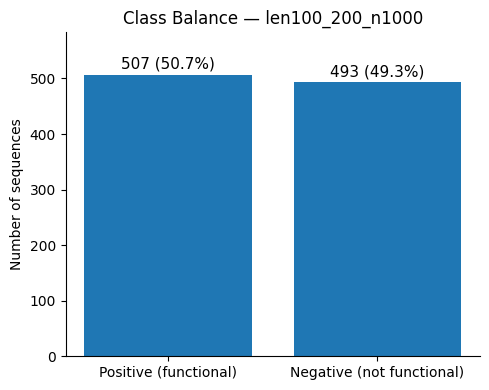

In [5]:
counts = [sum(labels), len(labels) - sum(labels)]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Positive (functional)", "Negative (not functional)"],
              counts,linewidth=0.8)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f"{count} ({100*count/len(labels):.1f}%)",
            ha="center", va="bottom", fontsize=11)

ax.set_ylabel("Number of sequences")
ax.set_title("Class Balance — len100_200_n1000")
ax.set_ylim(0, max(counts) * 1.15)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("class_balance_small.png", dpi=150)
plt.show()

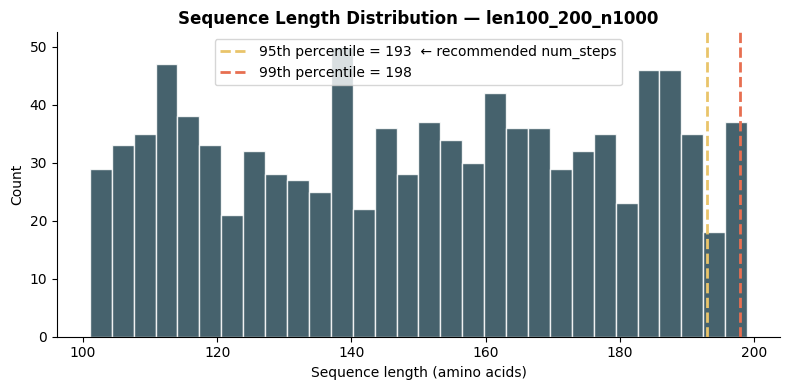


>>> Recommended num_steps = 193
    (covers 95% of sequences; only 5% get truncated)


In [6]:
p95 = int(np.percentile(lengths, 95))
p99 = int(np.percentile(lengths, 99))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lengths, bins=30, color="#264653", edgecolor="white", alpha=0.85)
ax.axvline(p95, color="#e9c46a", linestyle="--", linewidth=2,
           label=f"95th percentile = {p95}  ← recommended num_steps")
ax.axvline(p99, color="#e76f51", linestyle="--", linewidth=2,
           label=f"99th percentile = {p99}")

ax.set_xlabel("Sequence length (amino acids)")
ax.set_ylabel("Count")
ax.set_title("Sequence Length Distribution — len100_200_n1000", fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("length_dist_small.png", dpi=150)
plt.show()

print(f"\n>>> Recommended num_steps = {p95}")
print(f"    (covers 95% of sequences; only 5% get truncated)")

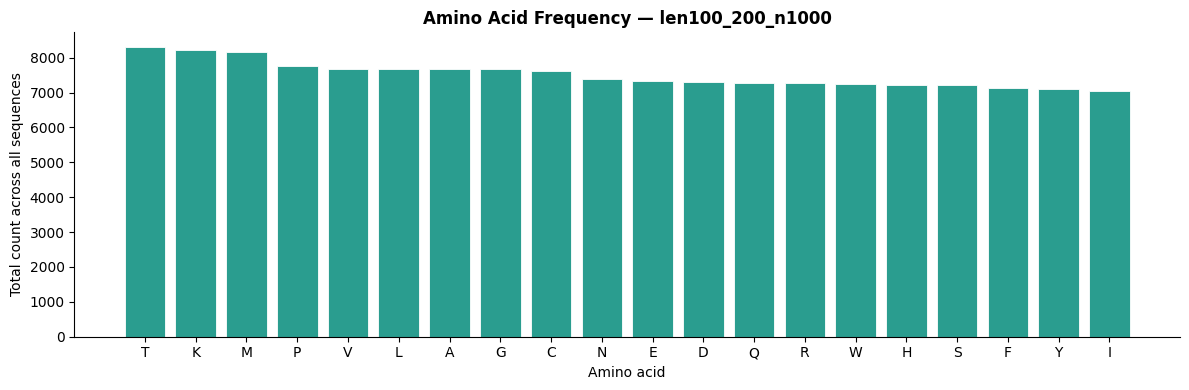

In [7]:
aa_freq = aa_frequency(sequences)
aas  = list(aa_freq.keys())
cnts = list(aa_freq.values())

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(aas, cnts, color="#2a9d8f", edgecolor="white", linewidth=0.6)
ax.set_xlabel("Amino acid")
ax.set_ylabel("Total count across all sequences")
ax.set_title("Amino Acid Frequency — len100_200_n1000", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("aa_freq_small.png", dpi=150)
plt.show()

In [8]:
sequences_l, labels_l = read("len200_500_n5000nr1.seq", "len200_500_n5000nr1.pos")
lengths_l = dataset_summary(sequences_l, labels_l, name="len200_500_n5000nr1")

p95_l = int(np.percentile(lengths_l, 95))
print(f">>> Recommended num_steps (large dataset) = {p95_l}")


  Dataset          : len200_500_n5000nr1
  Total sequences  : 5,000
  Positives (1)    : 2,467  (49.3%)
  Negatives (0)    : 2,533  (50.7%)
  Length  min      : 201
  Length  max      : 499
  Length  mean     : 350.1
  Length  median   : 350
  Length  95th pct : 485  <-- recommended num_steps
  Length  99th pct : 497

>>> Recommended num_steps (large dataset) = 485


In [9]:
lengths_s = [len(s) for s in sequences]

print("=" * 52)
print("DAY 1 LOG")
print("=" * 52)
print(f"\nSmall dataset  (len100_200_n1000)")
print(f"  Sequences    : {len(sequences)}")
print(f"  Positives    : {sum(labels)}  ({100*sum(labels)/len(labels):.1f}%)")
print(f"  Negatives    : {len(labels)-sum(labels)}  ({100*(len(labels)-sum(labels))/len(labels):.1f}%)")
print(f"  Length range : {min(lengths_s)} – {max(lengths_s)}")
print(f"  Length mean  : {np.mean(lengths_s):.1f}")
print(f"  num_steps    : {int(np.percentile(lengths_s, 95))}")

print(f"\nLarge dataset  (len200_500_n5000nr1)")
print(f"  Sequences    : {len(sequences_l)}")
print(f"  Positives    : {sum(labels_l)}  ({100*sum(labels_l)/len(labels_l):.1f}%)")
print(f"  Negatives    : {len(labels_l)-sum(labels_l)}  ({100*(len(labels_l)-sum(labels_l))/len(labels_l):.1f}%)")
print(f"  Length range : {min(lengths_l)} – {max(lengths_l)}")
print(f"  Length mean  : {np.mean(lengths_l):.1f}")
print(f"  num_steps    : {int(np.percentile(lengths_l, 95))}")
print("=" * 52)

DAY 1 LOG

Small dataset  (len100_200_n1000)
  Sequences    : 1000
  Positives    : 507  (50.7%)
  Negatives    : 493  (49.3%)
  Length range : 101 – 199
  Length mean  : 150.3
  num_steps    : 193

Large dataset  (len200_500_n5000nr1)
  Sequences    : 5000
  Positives    : 2467  (49.3%)
  Negatives    : 2533  (50.7%)
  Length range : 201 – 499
  Length mean  : 350.1
  num_steps    : 485


In [15]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

In [16]:
# Follows the project skeleton: tokenize → truncate/pad → one-hot → DataLoader

AA_ALPHABET = list("ACDEFGHIKLMNPQRSTVWY")
MAP_AA2NUM  = {aa: i for i, aa in enumerate(AA_ALPHABET)}


def generate_train_test(datalist, labellist, test_size=0.2, random_state=42):
    """
    Split into train and test sets.
    stratify= keeps the same pos/neg ratio in both splits.
    """
    tr_seq, te_seq, tr_lab, te_lab = train_test_split(
        datalist, labellist,
        test_size=test_size,
        stratify=labellist,
        random_state=random_state
    )
    print(f"Train : {len(tr_seq)} sequences  (pos={sum(tr_lab)})")
    print(f"Test  : {len(te_seq)} sequences  (pos={sum(te_lab)})")
    return (tr_seq, tr_lab), (te_seq, te_lab)


def tokenize(datalist, map2num, non_aa_num=20):
    """Convert sequences to integer lists. Follows project skeleton."""
    seq = []
    for s in datalist:
        seq.append([map2num.get(aa, non_aa_num) for aa in s])
    return seq


def truncate_pad(line, num_steps, padding_token=20):
    """Truncate or pad a sequence to exactly num_steps. Follows project skeleton."""
    if len(line) > num_steps:
        return line[:num_steps]
    return line + [padding_token] * (num_steps - len(line))


def build_seq_array(lines, num_steps):
    """Stack all sequences into one integer tensor [N, num_steps]."""
    return torch.tensor([truncate_pad(l, num_steps) for l in lines])


def one_hot_encode(seq_array, vocab_size=20):
    """
    Convert integer tensor [N, num_steps] → one-hot float tensor [N, 20, num_steps].

    Each position becomes a 20-dim vector: one 1 at the amino acid index, rest 0s.
    Padding positions (index 20) stay all-zero — no signal for padding.
    The output shape [N, 20, num_steps] is exactly what Conv1d expects.
    """
    N, L    = seq_array.shape
    one_hot = torch.zeros(N, vocab_size, L)
    for i in range(N):
        for j in range(L):
            idx = seq_array[i, j].item()
            if idx < vocab_size:        # skip padding token (index 20)
                one_hot[i, idx, j] = 1.0
    return one_hot


def load_data(batch_size, num_steps, dataset, shuffle=True):
    """
    Full pipeline: tokenize → pad/truncate → one-hot → DataLoader.

    dataset : (list_of_sequences, list_of_labels)
    Returns batches of (X, y) where
        X : FloatTensor [batch, 20, num_steps]   one-hot encoded
        y : FloatTensor [batch]                  0.0 or 1.0
    """
    seq, lab  = dataset
    seq       = tokenize(seq, MAP_AA2NUM)       # list of int lists
    seq_array = build_seq_array(seq, num_steps) # [N, num_steps]
    X         = one_hot_encode(seq_array)       # [N, 20, num_steps]
    y         = torch.tensor(lab, dtype=torch.float32)
    ds        = TensorDataset(X, y)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


print("Workstream 1 — preprocessing functions defined.")

Workstream 1 — preprocessing functions defined.


In [17]:
NUM_STEPS  = int(np.percentile([len(s) for s in sequences], 95))
BATCH_SIZE = 32
print(f"num_steps  = {NUM_STEPS}")
print(f"batch_size = {BATCH_SIZE}\n")

train_dataset, test_dataset = generate_train_test(sequences, labels)

train_iter = load_data(BATCH_SIZE, NUM_STEPS, train_dataset, shuffle=True)
test_iter  = load_data(BATCH_SIZE, NUM_STEPS, test_dataset,  shuffle=False)

# Shape check
X_batch, y_batch = next(iter(train_iter))
print(f"\nBatch X shape : {X_batch.shape}")   # [32, 20, NUM_STEPS]
print(f"Batch y shape : {y_batch.shape}")     # [32]
print(f"X dtype       : {X_batch.dtype}")     # torch.float32
print(f"y unique vals : {y_batch.unique()}")  # tensor([0., 1.])

# Verify one-hot: each non-padding column should sum to 1.0
col_sums = X_batch[0].sum(dim=0)
print(f"\nColumn sums (first 5 positions): {col_sums[:5].tolist()}")
print("(each value should be 1.0 for amino acids, 0.0 for padding)")

num_steps  = 193
batch_size = 32

Train : 800 sequences  (pos=406)
Test  : 200 sequences  (pos=101)

Batch X shape : torch.Size([32, 20, 193])
Batch y shape : torch.Size([32])
X dtype       : torch.float32
y unique vals : tensor([0., 1.])

Column sums (first 5 positions): [1.0, 1.0, 1.0, 1.0, 1.0]
(each value should be 1.0 for amino acids, 0.0 for padding)


In [18]:
class ProteinCNN(nn.Module):
    """
    1-D CNN for protein sequence classification.

    Input  : one-hot encoded sequences  [batch, 20, num_steps]
    Output : one logit per sequence     [batch, 1]

    Flow:
      Conv1d  ->  ReLU  ->  GlobalMaxPool  ->  Dropout  ->  Linear

    No Embedding layer needed — one-hot input goes straight into Conv1d.
    in_channels=20 matches the 20 amino acid channels from one-hot encoding.

    Train with BCEWithLogitsLoss (includes sigmoid — do not add sigmoid here).
    Use torch.sigmoid(output) to get probabilities at inference time.
    """

    def __init__(self, num_filters=64, kernel_size=15, dropout=0.3):
        super().__init__()

        # 20 input channels = 20 amino acids from one-hot encoding
        # num_filters = how many different motif patterns to search for
        # kernel_size = width of each motif window in amino acids
        self.conv    = nn.Conv1d(in_channels=20,
                                 out_channels=num_filters,
                                 kernel_size=kernel_size,
                                 padding=kernel_size // 2)
        self.relu    = nn.ReLU()

        # Global max pool: "did this motif appear ANYWHERE in the sequence?"
        # Collapses [batch, num_filters, L] -> [batch, num_filters]
        self.pool    = nn.AdaptiveMaxPool1d(1)

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(num_filters, 1)

    def forward(self, x):
        # x : [batch, 20, num_steps]  already correct shape for Conv1d
        x = self.relu(self.conv(x))  # [batch, num_filters, num_steps]
        x = self.pool(x).squeeze(-1) # [batch, num_filters]
        x = self.dropout(x)
        x = self.fc(x)               # [batch, 1]
        return x


print("Workstream 2 — ProteinCNN defined.")

Workstream 2 — ProteinCNN defined.


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

model = ProteinCNN(num_filters=64, kernel_size=15, dropout=0.3).to(device)

print(model)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")

X_batch, y_batch = next(iter(train_iter))
X_batch = X_batch.to(device)

model.eval()
with torch.no_grad():
    logits = model(X_batch)                   # [32, 1]
    probs  = torch.sigmoid(logits).squeeze()  # [32]

print(f"\nInput  shape : {X_batch.shape}")    # [32, 20, NUM_STEPS]
print(f"Output shape : {logits.shape}")       # [32, 1]
print(f"Probs  range : [{probs.min():.3f}, {probs.max():.3f}]")

assert logits.shape == (BATCH_SIZE, 1), f"Wrong output shape: {logits.shape}"
assert 0 < probs.min() < 1 and 0 < probs.max() < 1, "Probabilities out of range"

print("\nAll checks passed — ready for Day 3 training!")

Device: cpu

ProteinCNN(
  (conv): Conv1d(20, 64, kernel_size=(15,), stride=(1,), padding=(7,))
  (relu): ReLU()
  (pool): AdaptiveMaxPool1d(output_size=1)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Trainable parameters: 19,329

Input  shape : torch.Size([32, 20, 193])
Output shape : torch.Size([32, 1])
Probs  range : [0.454, 0.475]

All checks passed — ready for Day 3 training!


In [20]:
def train_epoch(model, data_iter, optimizer, criterion, device):
    """
    Run one full pass over the training data.
    Returns average loss and accuracy for this epoch.
    """
    model.train()   # turns dropout ON
    total_loss, correct, total = 0, 0, 0

    for X, y in data_iter:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()              # clear old gradients
        logits = model(X).squeeze()        # [batch, 1] -> [batch]
        loss   = criterion(logits, y)      # BCEWithLogitsLoss
        loss.backward()                    # compute gradients
        optimizer.step()                   # update weights

        total_loss += loss.item()
        preds   = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == y).sum().item()
        total   += y.size(0)

    avg_loss = total_loss / len(data_iter)
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate(model, data_iter, criterion, device):
    """
    Evaluate on test set.
    Returns average loss, accuracy, and AUC.
    """
    model.eval()    # turns dropout OFF
    total_loss, correct, total = 0, 0, 0
    all_probs, all_labels = [], []

    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)

            logits = model(X).squeeze()
            loss   = criterion(logits, y)
            probs  = torch.sigmoid(logits)

            total_loss += loss.item()
            preds   = (probs > 0.5).float()
            correct += (preds == y).sum().item()
            total   += y.size(0)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    avg_loss = total_loss / len(data_iter)
    accuracy = correct / total
    auc      = roc_auc_score(all_labels, all_probs)
    return avg_loss, accuracy, auc


print("train_epoch() and evaluate() defined.")

train_epoch() and evaluate() defined.


In [25]:
def one_hot_encode(seq_array, vocab_size=20):
    N, L    = seq_array.shape
    one_hot = torch.zeros(N, vocab_size, L)
    mask    = seq_array < vocab_size
    idx     = seq_array.clamp(0, vocab_size - 1)
    one_hot.scatter_(1, idx.unsqueeze(1), 1.0)
    one_hot *= mask.unsqueeze(1)
    return one_hot

print("Fast one_hot_encode defined.")

Fast one_hot_encode defined.


In [26]:
# ── Cell 21: Train and evaluate on the large dataset ─────────────────────────

# Load large dataset
sequences_large, labels_large = read("len200_500_n5000nr1.seq",
                                     "len200_500_n5000nr1.pos")

# New num_steps for longer sequences
NUM_STEPS_LARGE = int(np.percentile([len(s) for s in sequences_large], 95))
print(f"num_steps (large) = {NUM_STEPS_LARGE}")

# Split and build DataLoaders
train_large, test_large = generate_train_test(sequences_large, labels_large)
train_iter_l = load_data(BATCH_SIZE, NUM_STEPS_LARGE, train_large, shuffle=True)
test_iter_l  = load_data(BATCH_SIZE, NUM_STEPS_LARGE, test_large,  shuffle=False)

# Fresh model — same architecture, same hyperparameters
model_large = ProteinCNN(num_filters=64, kernel_size=15, dropout=0.3).to(device)
criterion   = nn.BCEWithLogitsLoss()
optimizer   = torch.optim.Adam(model_large.parameters(), lr=0.001)

# Train for 20 epochs
print(f"\n{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Test Loss':>9}  {'Test Acc':>8}  {'AUC':>6}")
print("-" * 60)

for epoch in range(1, 21):
    tr_loss, tr_acc          = train_epoch(model_large, train_iter_l, optimizer, criterion, device)
    te_loss, te_acc, te_auc  = evaluate(model_large, test_iter_l, criterion, device)
    print(f"{epoch:>5}  {tr_loss:>10.4f}  {tr_acc:>9.3f}  {te_loss:>9.4f}  {te_acc:>8.3f}  {te_auc:>6.3f}")

print("-" * 60)
print(f"\nSmall dataset — Test acc: {history['test_acc'][-1]:.3f}  AUC: {history['test_auc'][-1]:.3f}")
print(f"Large dataset — Test acc: {te_acc:.3f}  AUC: {te_auc:.3f}")

num_steps (large) = 485
Train : 4000 sequences  (pos=1974)
Test  : 1000 sequences  (pos=493)

Epoch  Train Loss  Train Acc  Test Loss  Test Acc     AUC
------------------------------------------------------------
    1      0.5361      0.798     0.2090     1.000   1.000
    2      0.0912      1.000     0.0279     1.000   1.000
    3      0.0226      1.000     0.0099     1.000   1.000
    4      0.0110      1.000     0.0051     1.000   1.000
    5      0.0066      1.000     0.0031     1.000   1.000
    6      0.0042      1.000     0.0023     1.000   1.000
    7      0.0031      1.000     0.0016     1.000   1.000
    8      0.0027      1.000     0.0012     1.000   1.000
    9      0.0022      1.000     0.0010     1.000   1.000
   10      0.0015      1.000     0.0008     1.000   1.000
   11      0.0015      1.000     0.0007     1.000   1.000
   12      0.0010      1.000     0.0005     1.000   1.000
   13      0.0012      1.000     0.0005     1.000   1.000
   14      0.0007      1.000     

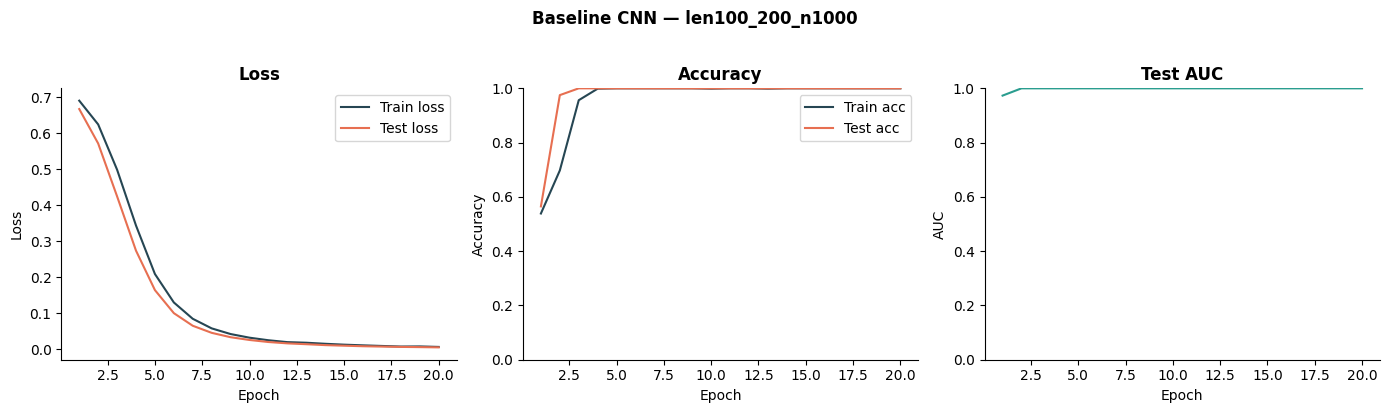

In [27]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Loss
axes[0].plot(epochs, history["train_loss"], label="Train loss", color="#264653")
axes[0].plot(epochs, history["test_loss"],  label="Test loss",  color="#e76f51")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss", fontweight="bold")
axes[0].legend()
axes[0].spines[["top", "right"]].set_visible(False)

# Accuracy
axes[1].plot(epochs, history["train_acc"], label="Train acc", color="#264653")
axes[1].plot(epochs, history["test_acc"],  label="Test acc",  color="#e76f51")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy", fontweight="bold")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)

# AUC
axes[2].plot(epochs, history["test_auc"], color="#2a9d8f")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("AUC")
axes[2].set_title("Test AUC", fontweight="bold")
axes[2].set_ylim(0, 1)
axes[2].spines[["top", "right"]].set_visible(False)

plt.suptitle("Baseline CNN — len100_200_n1000", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("training_curves_baseline.png", dpi=150)
plt.show()

In [24]:
print("=" * 52)
print("DAY 3 LOG — Baseline result")
print("=" * 52)
print(f"  Dataset      : len100_200_n1000")
print(f"  num_filters  : 64")
print(f"  kernel_size  : 15")
print(f"  dropout      : 0.3")
print(f"  learning_rate: 0.001")
print(f"  epochs       : {NUM_EPOCHS}")
print(f"  batch_size   : {BATCH_SIZE}")
print(f"  num_steps    : {NUM_STEPS}")
print(f"  ---")
print(f"  Train acc    : {history['train_acc'][-1]:.3f}")
print(f"  Test  acc    : {history['test_acc'][-1]:.3f}")
print(f"  Test  AUC    : {history['test_auc'][-1]:.3f}")
print("=" * 52)

# Checkpoint check — project requires >75% accuracy by April 16
if history["test_acc"][-1] >= 0.75:
    print("\nCheckpoint PASSED — test accuracy above 75%")
else:
    print("\nCheckpoint NOT YET MET — test accuracy below 75%")
    print("Try: more epochs, lower dropout, or larger kernel_size")

DAY 3 LOG — Baseline result
  Dataset      : len100_200_n1000
  num_filters  : 64
  kernel_size  : 15
  dropout      : 0.3
  learning_rate: 0.001
  epochs       : 20
  batch_size   : 32
  num_steps    : 193
  ---
  Train acc    : 1.000
  Test  acc    : 1.000
  Test  AUC    : 1.000

Checkpoint PASSED — test accuracy above 75%
